In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset 
df = pd.read_csv('Titanic_EDA.csv')  
# Quick peek to ensure it loaded
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# Check missing values
print("Before cleaning:\n", df.isnull().sum())

# Age -> Fill with Median (No inplace=True warning)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked -> Fill with Mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin -> Drop entirely. 'errors=ignore' prevents KeyError if run twice
df = df.drop('Cabin', axis=1, errors='ignore')

print("\nAfter cleaning:\n", df.isnull().sum())

Before cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

After cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Cleaning Strategy: I used fillna() instead of dropna() for 'Age' because losing 177 rows (~20%) would shrink the dataset too much. I used the median because Age has some skew. I dropped 'Cabin' entirely because 687 out of 891 values were missing—any imputation here would be pure guesswork. For 'Embarked', I used the mode since only 2 values were missing.



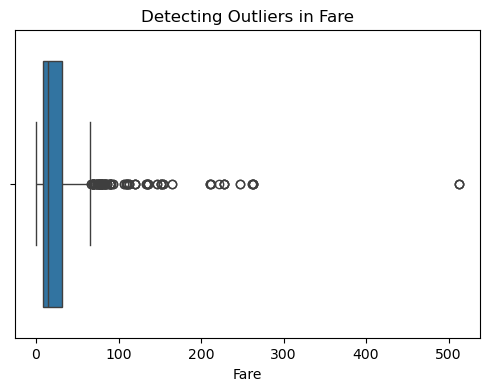

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Fare'])
plt.title('Detecting Outliers in Fare')
plt.show()

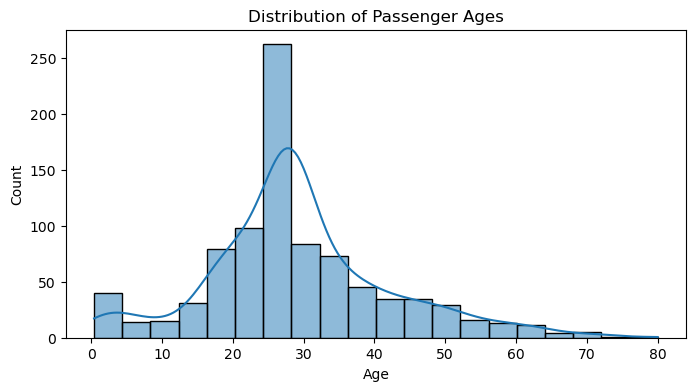

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

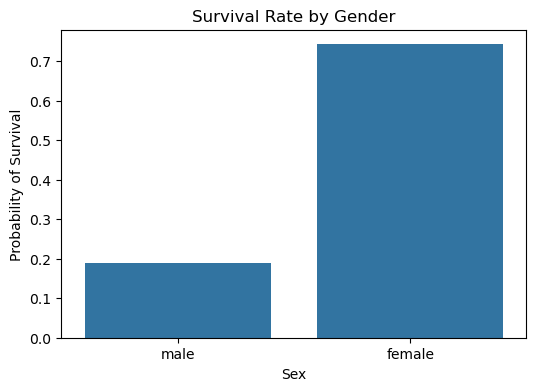

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=df, errorbar=None)
plt.title('Survival Rate by Gender')
plt.ylabel('Probability of Survival')
plt.show()

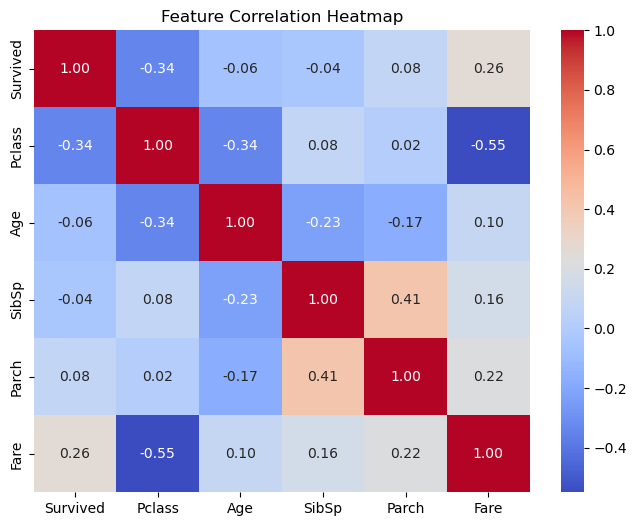

In [12]:
plt.figure(figsize=(8,6))
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

Which feature most affects survival, and why?
Based on the visualizations, `Sex` (Gender) is the strongest predictor of survival.

The **bar chart** clearly shows the gap: females had a survival rate of approximately **74%**, while males survived at only **~19%**. This is further backed by the **correlation heatmap**, where `Sex` shows a strong negative correlation of **-0.54** with survival (since male was encoded as 1, female as 0). 

While `Pclass` also plays a significant role (first-class passengers had better survival odds), gender dominates because of the historical "women and children first" evacuation protocol followed during the Titanic disaster. Simply put, being female drastically increased your chances of getting a lifeboat seat.